The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Widget(value='<iframe src="http://localhost:54720/index.html?ui=P_0x35943a6f0_0&reconnect=auto" class="pyvista…

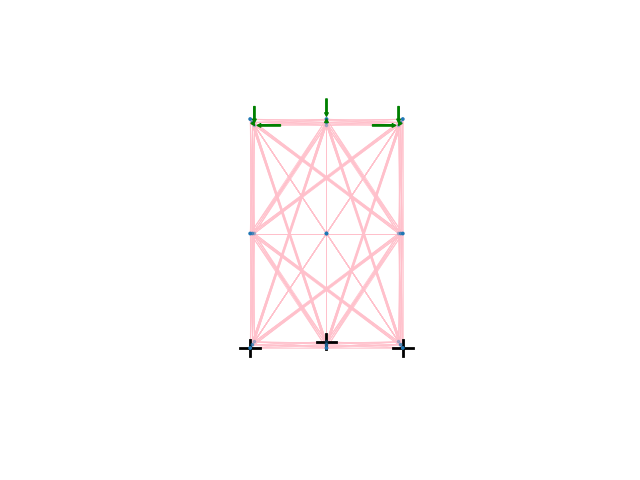

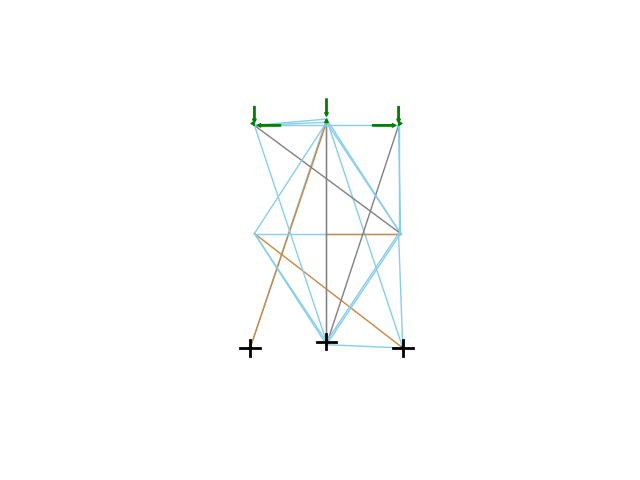

In [1]:
import numpy as np
np.set_printoptions(threshold = np.inf)
import pandas as pd
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
import mpl_toolkits.mplot3d as a3
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D
%matplotlib widget


# --------------------------------------------- Load Optimized Data ----------------------------------------------

plot_load_scale = 1/10
plot_bc_scale = 1/30

A = pd.read_csv('Data_A.csv').to_numpy()[:,1:]
q = pd.read_csv('Data_q.csv').to_numpy()[:,1:]
q_cor = pd.read_csv('Data_q_cor.csv').to_numpy()[:,1:]
z = pd.read_csv('Data_z.csv').to_numpy()[:,1:]

dof = pd.read_csv('Data_dof.csv').to_numpy()[:,1]
F = pd.read_csv('Data_F.csv').to_numpy()[:,1:]
ien = pd.read_csv('Data_ien.csv').to_numpy()[:,1:]
load_colors = pd.read_csv('Data_load_colors.csv').values[:,1].tolist()
material_colors = pd.read_csv('Data_mat_colors.csv').values[:,1].tolist()
load_colors = pd.read_csv('Data_load_colors.csv').values[:,1].tolist()
nodes = pd.read_csv('Data_nodes.csv').to_numpy()[:,1:]

L_C = np.shape(q)[1]
N = np.shape(A)[0]
N_F = len(dof)
M = np.shape(A)[1]


# ----------------------------------------- Define 3D Arrows for Plots -------------------------------------------

class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)
    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)
        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)
        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)
    
def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    '''Add an 3d arrow to an `Axes3D` instance.'''
    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)
setattr(Axes3D, 'arrow3D', _arrow3D)


# ------------------------------------------- Plot Ground Structure ---------------------------------------------

x_dim = max(nodes[:,0]) - min(nodes[:,0])
x_mid = np.average(np.array([max(nodes[:,0]), min(nodes[:,0])]))
y_dim = max(nodes[:,1]) - min(nodes[:,1])
y_mid = np.average(np.array([max(nodes[:,1]), min(nodes[:,1])]))
z_dim = max(nodes[:,2]) - min(nodes[:,2])
z_mid = np.average(np.array([max(nodes[:,2]), min(nodes[:,2])]))
dim = max(x_dim, y_dim, z_dim)

fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection = '3d')
ax1.plot([0, dim], [0, dim], [0, dim], color = 'w', linewidth = 0)
ax1.scatter(nodes[:,0], nodes[:,1], nodes[:,2], s = 3)
for i in range(len(ien)):
    node1 = ien[i, 0].astype(int)
    node2 = ien[i, 1].astype(int)
    x0 = [nodes[node1, 0], nodes[node2, 0]]
    y0 = [nodes[node1, 1], nodes[node2, 1]]
    z0 = [nodes[node1, 2], nodes[node2, 2]]
    ax1.plot(x0, y0, z0, color = 'pink', linewidth = 1/2)
ax1.view_init(elev = 0, azim = -90)
ax1.axes.set_xlim3d(left = x_dim/2 - dim/2, right = x_dim/2 + dim/2) 
ax1.axes.set_ylim3d(bottom = y_dim/2 - dim/2, top = y_dim/2 + dim/2) 
ax1.axes.set_zlim3d(bottom = 0, top = dim)
ax1.axis('off')
            
# Plot Boundary and Loading Conditions
index = 0
for i in range(len(dof)):
    if index == 0:
        index = 1
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], \
                    [nodes.flatten()[i + 2], nodes.flatten()[i + 2]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i],
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    elif index == 1:
        index = 2
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i],
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    else:
        index = 0
        if dof[i] == 0:
            ax1.plot([nodes.flatten()[i - 2], nodes.flatten()[i - 2]], \
                    [nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                        color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax1.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i],
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax1.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])


# ------------------------------------------ Plot Optimized Structure -------------------------------------------

# Isometric View
fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection = '3d') # , proj_type = 'ortho'
for i in range(N):
    for j in range(M):
        if z[i,j] > 0:
            node1 = ien[i, 0].astype(int)
            node2 = ien[i, 1].astype(int)
            x0 = [nodes[node1, 0], nodes[node2, 0]]
            y0 = [nodes[node1, 1], nodes[node2, 1]]
            z0 = [nodes[node1, 2], nodes[node2, 2]]
            ax2.plot(x0, y0, z0, color = material_colors[j], linewidth = 1) #A[i,j]/A.max()
ax2.view_init(elev = 0, azim = -90)
ax2.axes.set_xlim3d(left = x_mid - dim/2, right = x_mid + dim/2) 
ax2.axes.set_ylim3d(bottom = y_mid - dim/2, top = y_mid + dim/2) 
ax2.axes.set_zlim3d(bottom = z_mid - dim/2, top = z_mid + dim/2)
ax2.axis('off')
            
# Plot Boundary and Loading Conditions
index = 0
for i in range(len(dof)):
    if index == 0:
        index = 1
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], \
                    [nodes.flatten()[i + 2], nodes.flatten()[i + 2]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i],
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                y = nodes.flatten()[i + 1],
                                z = nodes.flatten()[i + 2],
                                dx = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dy = 0,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    elif index == 1:
        index = 2
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                    [nodes.flatten()[i + 1], nodes.flatten()[i + 1]], color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i],
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 1],
                                y = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                z = nodes.flatten()[i + 1],
                                dx = 0,
                                dy = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dz = 0,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

    else:
        index = 0
        if dof[i] == 0:
            ax2.plot([nodes.flatten()[i - 2], nodes.flatten()[i - 2]], \
                    [nodes.flatten()[i - 1], nodes.flatten()[i - 1]], \
                    [nodes.flatten()[i] - dim*plot_bc_scale, nodes.flatten()[i] + dim*plot_bc_scale], \
                        color = 'black', linewidth = 2)
        for h in range(np.shape(F)[1]):
            if F[i,h] != 0:
                if abs(F[i,h]) < 0:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i],
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])
                else:
                    ax2.arrow3D(x = nodes.flatten()[i - 2],
                                y = nodes.flatten()[i - 1],
                                z = nodes.flatten()[i] - F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                dx = 0,
                                dy = 0,
                                dz = F[i,h]/abs(F[i,h])*dim*plot_load_scale,
                                mutation_scale = 5, ec = load_colors[h], fc = load_colors[h])

fig1.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
fig2.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)

# Save Figures
fig1.savefig('Image_Ground_Structure.eps', format = 'eps')
fig1.savefig('Image_Ground_Structure.png', format = 'png', dpi = 1000)
fig2.savefig('Image_Design.eps', format = 'eps')
fig2.savefig('Image_Design.png', format = 'png', dpi = 1000)


# ---------------------------------------- Generate Structural Rendering ----------------------------------------
import pyvista as pv
from trame.widgets import vuetify

# Define Rendering Space
plotter = pv.Plotter(window_size=[int(3840/3), int(2160/3)]) # Rough Render
# plotter = pv.Plotter(window_size=[int(3840*2), int(2160*2)]) # Detail Render

# Render Ground Structure
# for i in range(N):
#     node1 = ien[i, 0].astype(int)
#     node2 = ien[i, 1].astype(int)
#     line = pv.Line(nodes[node1,:], nodes[node2,:])
#     tube = line.tube(radius = 0.001*dim)
#     plotter.add_mesh(tube, color = 'pink')
# for i in range(len(nodes)):
#     node_sphere = pv.Sphere(radius = 0.005*dim, center = nodes[i,:])
#     plotter.add_mesh(node_sphere, color = 'blue')

# Render Design
for i in range(N):
    for j in range(M):
        if A[i,j] > 1e-4:
            node1 = ien[i, 0].astype(int)
            node2 = ien[i, 1].astype(int)
            line = pv.Line(nodes[node1,:], nodes[node2,:])
            tube = line.tube(radius = np.sqrt(A[i,j]/np.pi)/10)
            plotter.add_mesh(tube, color = material_colors[j])
            # if j == 0:
            #     plotter.add_mesh(tube, color = material_colors[j], opacity=1)
            # else:
            #     plotter.add_mesh(tube, color = material_colors[j], opacity=0.05) # 0.1

# Render Design Stresses
# stress_scale = 8
# for i in range(N):
#     for j in range(M):
#         if A[i,j] > 1e-4:
#             node1 = ien[i, 0].astype(int)
#             node2 = ien[i, 1].astype(int)
#             if q[i] > 0:
#                 plotter.add_lines(np.array([nodes[node1,:], nodes[node2,:]]),
#                                   color = 'red',
#                                   width = stress_scale*(q[i]/max(abs(q))) / (A[i,j]/np.max(A)))
#             elif q[i] < 0:
#                 plotter.add_lines(np.array([nodes[node1,:], nodes[node2,:]]),
#                                   color = 'blue',
#                                   width = -stress_scale*(q[i]/max(abs(q))) / (A[i,j]/np.max(A)))

# Render Boundary Conditions
h = dim/20
r = h/2
res = 20
col = "gray"
for k in range(N_F):
    # Plot BCs in x-Direction
    # if dof[k] == 0 and k%3 == 0:
    #     if nodes.flatten()[k] - x_mid <= 0:
    #         cone = pv.Cone(center = (nodes.flatten()[k]-h/2, nodes.flatten()[k+1], nodes.flatten()[k+2]),
    #                        direction = (1, 0, 0),
    #                        height = h,
    #                        radius = r,
    #                        resolution = res)
    #     elif nodes.flatten()[k] - x_mid >= 0:
    #         cone = pv.Cone(center = (nodes.flatten()[k]+h/2, nodes.flatten()[k+1], nodes.flatten()[k+2]),
    #                        direction = (-1, 0, 0),
    #                        height = h,
    #                        radius = r,
    #                        resolution = res)
    #     plotter.add_mesh(cone, color = col, show_edges = False)
    # Plot BCs in y-Direction
    # if dof[k] == 0 and k%3 == 1:
    #     if nodes.flatten()[k] - y_mid <= 0:
    #         cone = pv.Cone(center = (nodes.flatten()[k-1], nodes.flatten()[k]-h/2, nodes.flatten()[k+1]),
    #                        direction = (0, 1, 0),
    #                        height = h,
    #                        radius = r,
    #                        resolution = res)
    #     elif nodes.flatten()[k] - y_mid >= 0:
    #         cone = pv.Cone(center = (nodes.flatten()[k-1], nodes.flatten()[k]+h/2, nodes.flatten()[k+1]),
    #                        direction = (0, -1, 0),
    #                        height = h,
    #                        radius = r,
    #                        resolution = res)
    #     plotter.add_mesh(cone, color = col, show_edges = False)
    # Plot BCs in z-Direction
    if dof[k] == 0 and k%3 == 2:
        if nodes.flatten()[k] - z_mid <= 0:
            cone = pv.Cone(center = (nodes.flatten()[k-2], nodes.flatten()[k-1], nodes.flatten()[k]-h/2),
                           direction = (0, 0, 1),
                           height = h,
                           radius = r,
                           resolution = res)
        elif nodes.flatten()[k] - z_mid >= 0:
            cone = pv.Cone(center = (nodes.flatten()[k-2], nodes.flatten()[k-1], nodes.flatten()[k]+h/2),
                           direction = (0, 0, -1),
                           height = h,
                           radius = r,
                           resolution = res)
        plotter.add_mesh(cone, color = col, show_edges = False)

# Render Loads
# load_scale = 0.1*dim
# arrow_to_node = False # Plots load arrow pointing towards node when 'True' and away from node when "False".
# for k in range(N_F):
#     for h in range(L_C):
#         if F[k,h] != 0 and k%3 == 0:
#             sign = F[k,h]/abs(F[k,h])
#             load_mag = 1/2
#             if arrow_to_node == True:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k]-sign*load_scale*load_mag, nodes.flatten()[k+1], nodes.flatten()[k+2]),
#                                 direction = (sign, 0, 0),
#                                 scale = load_scale*load_mag)
#             elif arrow_to_node == False:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k], nodes.flatten()[k+1], nodes.flatten()[k+2]),
#                                 direction = (sign, 0, 0),
#                                 scale = load_scale*load_mag)
#             plotter.add_mesh(arrow, color = load_colors[h], show_edges = False)
#         if F[k,h] != 0 and k%3 == 1:
#             sign = F[k,h]/abs(F[k,h])
#             load_mag = 1/2
#             if arrow_to_node == True:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k-1], nodes.flatten()[k]-sign*load_scale*load_mag, nodes.flatten()[k+1]),
#                                 direction = (0, sign, 0),
#                                 scale = load_scale*load_mag)
#             elif arrow_to_node == False:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k-1], nodes.flatten()[k], nodes.flatten()[k+1]),
#                                 direction = (0, sign, 0),
#                                 scale = load_scale*load_mag)
#             plotter.add_mesh(arrow, color = load_colors[h], show_edges = False)
#         elif F[k,h] != 0 and k%3 == 2:
#             sign = F[k,h]/abs(F[k,h])
#             load_mag = 1
#             if arrow_to_node == False:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k-2], nodes.flatten()[k-1], nodes.flatten()[k]-sign*load_scale*load_mag),
#                                 direction = (0, 0, sign),
#                                 scale = load_scale*load_mag)
#             elif arrow_to_node == True:
#                 arrow = pv.Arrow(start = (nodes.flatten()[k-2], nodes.flatten()[k-1], nodes.flatten()[k]),
#                                 direction = (0, 0, sign),
#                                 scale = load_scale*load_mag)
#             plotter.add_mesh(arrow, color = load_colors[h], show_edges = False)

# Generate Render and Position Camera
plotter.show(jupyter_backend='trame')
# plotter.camera_position = [
#     (x_mid, -18, z_mid),   # camera location
#     (x_mid, y_mid, z_mid),   # focal point (look at this point)
#     (0, 0, 1),   # view up direction
# ]

zoom = 4/5
plotter.camera_position = [
    # (12, -3, 8),   # camera location 0
    (13*zoom, -5*zoom, 8*zoom),   # camera location 0
    # (10, -8, 6),   # camera location 1
    # (-8, -8, 6),   # camera location 2
    # (-8, 10, 6),   # camera location 3
    # (10, 10, 6),   # camera location 4
    (1, 1, 2),   # focal point (look at this point)
    (0, 0, 1),   # view up direction
]